In [322]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, trapezoid, cumulative_trapezoid, solve_ivp
from scipy.interpolate import interp1d, CubicSpline
from scipy.special import factorial, gamma
from scipy.optimize import fsolve

# Cinética de Procesos (Sesión 05)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 5. Modelos de un parámetro

## 5.1 Modelo de tanques en serie

### 5.1.1 Ecuaciones del modelo

Debajo se presenta la ecuación RTD para $n$ tanques de igual tamaño en serie. Con un solo tanque, la curva RTD corresponde a la de un reactor CSTR, y cuando el número de tanques es muy grande, la curva RTD se aproxima a la de un reactor PFR.

$$E(t) = \frac{\displaystyle n(n\Theta)^{n-1}}{\displaystyle \tau\left(n-1\right)!} \exp \left(-n {\Theta}\right)$$

$$E(\Theta) = \tau E(t) = \frac{\displaystyle n(n\Theta)^{n-1}}{\displaystyle \left(n-1\right)!} \exp \left(-n {\Theta}\right)$$

$$\Theta = \frac{t}{\tau}$$

In [323]:
def Ncstr(t, tau, n):
    Th = t/tau                     #Γ(n+1)=n!
    return 1/tau * n*(n*Th)**(n-1)/gamma(n) * np.exp(-n*Th)

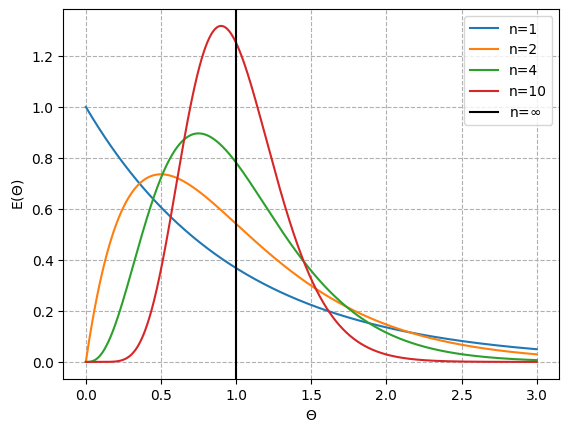

In [324]:
t = np.linspace(0, 3, 1001)
tau = 1.0

fig, ax = plt.subplots()
ntanks = [1, 2, 4, 10]
for n in ntanks:
    ax.plot(t, Ncstr(t, tau, n), label=f"n={n}")
ax.axvline(1, c='k', label=r"n=$\infty$")
ax.set_xlabel(r"$\Theta$")
ax.set_ylabel(r"E($\Theta$)")
ax.legend()
ax.grid(ls='--')
plt.show()

### 5.1.2 Estimación del número de tanques a modelar

El número de tanques en serie que son necesarios para modelar un reactor se puede estimar a partir de la varianza adimensional, $\sigma_{\Theta}^2$, de un experimento con trazador.

$$\sigma_{\Theta}^2 = \frac{\sigma^2}{\tau^2} = \int_0^\infty \left(\Theta - 1\right)^2 E\left(\Theta\right) d \Theta$$

$$\sigma_{\Theta}^2 = \int_0^\infty \Theta^2 E\left(\Theta\right) d \Theta - 1$$

$$\vdots$$

$$\sigma_{\Theta}^2 = \frac{1}{n}$$

Entonces se tiene:

$$n = \frac{1}{\sigma_{\Theta}^2} = \frac{\tau^2}{\sigma^2}$$

## 5.2 Ejemplos

### 5.2.1 Reacción de primer orden (Levenspiel)

En un reactor, cuya curva RTD se puede construir a partir de los datos $t$ vs $C$ mostrados debajo, se lleva a cabo una reacción de descomposición en fase líquida:

$$\mathrm{A \rightarrow B}$$

$$-r_{\mathrm{A}} = k C_{\mathrm{A}}$$

$$k=0.307\,\text{min}^{-1}$$

Calcule la conversión en el reactor real, usando los modelos segregado y de máximo mezclado, y compare contra reactores ideales del mismo tamaño.

In [325]:
### Datos
t = np.array([0, 5, 10, 15, 20, 25, 30, 35]) # min
C = np.array([0, 3, 5, 5, 4, 2, 1, 0]) # g/dm3

##### Tanques en serie

In [326]:
### Determinar el numero de tanques a modelar

# Curva C(t)
Cs = CubicSpline(t, C) # spline
# Curva E(t)
Es = CubicSpline(t, Cs(t)/Cs.integrate(t[0], t[-1])) # spline
# tau, sigma, ntanks
tr = CubicSpline(t, t*Es(t)).integrate(t[0], t[-1])  # mean residence time
s2 = CubicSpline(t, (t-tms)**2 * Es(t)).integrate(t[0], t[-1]) # variance
ntanks = tr**2/s2
ntanks = [
    int(np.floor(ntanks)), 
    int(np.floor(ntanks+1)),
    int(np.floor(ntanks+2))
]
#printouts
print(f"tau: {tr:.2f}")
print(f"s2 : {s2:.2f}")
print(f"n tanks: {tau**2/s2:.2f} --> {ntanks[0], ntanks[1]}")

tau: 14.89
s2 : 147.28
n tanks: 0.01 --> (1, 2)


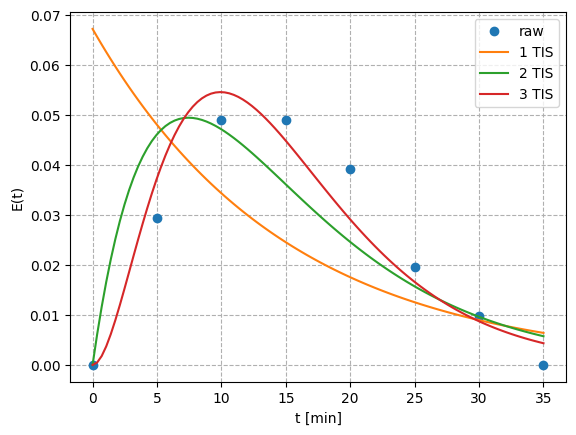

In [327]:
fig, ax = plt.subplots()
ax.plot(t, Es(t), ls='', marker='o', label=f"raw")
tt = np.linspace(t[0], t[-1], 100)
for ntank in ntanks:
    ax.plot(tt, Ncstr(tt, tr, ntank), label=f"{ntank} TIS")
ax.legend()
ax.grid(ls='--')
ax.set_xlabel("t [min]")
ax.set_ylabel("E(t)")
plt.show()

In [328]:
# calculo de cinetica con modelo de tanques en series (TIS)
cA0 = 1
k = 0.307 # 1/min
r_A = lambda cA: -k*cA
def cstrOptFun(cA, cA0, tau):
    return    cA0 - cA + tau*r_A(cA)

print("Conversion, X")
# conversion
for ntank in ntanks:
    tauTIS = tr/ntank
    cEntry = cA0
    for tank in range(ntank):
        cExit = fsolve(cstrOptFun, x0=cEntry, args=(cEntry, tauTIS))
        cEntry = cExit[0]
    x = 1 - cExit[0]/cA0 # conversion after n reactors
    print(f"{ntank} TIS: {x:.4f}")

Conversion, X
1 TIS: 0.8205
2 TIS: 0.9073
3 TIS: 0.9378


### 5.3.2 Reacción de primer orden (Fogler)

    Fogler, Ex. 17.2

Calcule la conversión promedio en un reactor caracterizado por las mediciones RTD que se muestran debajo, para una reacción de primer orden en fase líquida:

$$\mathrm{A \rightarrow B}$$

$$-r_{\mathrm{A}} = k C_{\mathrm{A}}$$

$$k=0.1\,\text{min}^{-1}$$

Calcule la conversión en el reactor real, usando los modelos segregado y de máximo mezclado, y compare contra reactores ideales del mismo tamaño.

In [329]:
### Datos
t = np.array([0, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14]) # min
C = np.array([0, 0.6, 1.4, 5, 8, 10, 8, 6, 4, 3, 2.2, 1.5, 0.6, 0]) # g/m3



##### Tanques en serie

In [330]:
### Determinar el numero de tanques a modelar

# Curva C(t)
Cs = CubicSpline(t, C) # spline
# Curva E(t)
Es = CubicSpline(t, Cs(t)/Cs.integrate(t[0], t[-1])) # spline
# tau, sigma, ntanks
tr = CubicSpline(t, t*Es(t)).integrate(t[0], t[-1])  # mean residence time
s2 = CubicSpline(t, (t-tms)**2 * Es(t)).integrate(t[0], t[-1]) # variance
ntanks = tr**2/s2
ntanks = [
    int(np.floor(ntanks)), 
    int(np.floor(ntanks+1)),
]
#printouts
print(f"tau: {tr:.2f}")
print(f"s2 : {s2:.2f}")
print(f"n tanks: {tau**2/s2:.2f} --> {ntanks[0], ntanks[1]}")

tau: 5.09
s2 : 6.22
n tanks: 0.16 --> (4, 5)


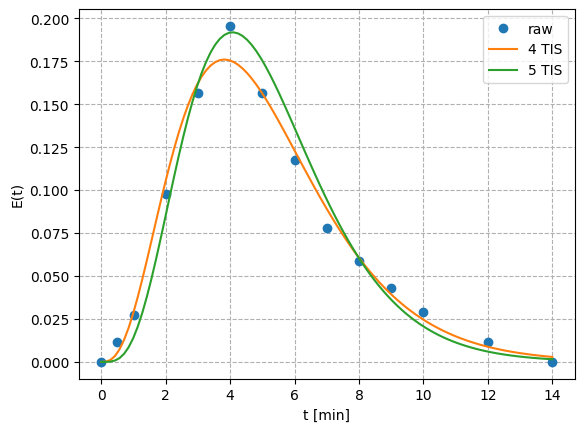

In [331]:
fig, ax = plt.subplots()
ax.plot(t, Es(t), ls='', marker='o', label=f"raw")
tt = np.linspace(t[0], t[-1], 100)
for ntank in ntanks:
    ax.plot(tt, Ncstr(tt, tr, ntank), label=f"{ntank} TIS")
ax.legend()
ax.grid(ls='--')
ax.set_xlabel("t [min]")
ax.set_ylabel("E(t)")
plt.show()

In [332]:
# calculo de cinetica con modelo de tanques en series (TIS)
cA0 = 1
k = 0.25 # 1/min
r_A = lambda cA: -k*cA
def cstrOptFun(cA, cA0, tau):
    return    cA0 - cA + tau*r_A(cA)

print("Conversion, X")
# conversion
for ntank in ntanks:
    tauTIS = tr/ntank
    cEntry = cA0
    for tank in range(ntank):
        cExit = fsolve(cstrOptFun, x0=cEntry, args=(cEntry, tauTIS))
        cEntry = cExit[0]
    x = 1 - cExit[0]/cA0 # conversion after n reactors
    print(f"{ntank} TIS: {x:.4f}")


Conversion, X
4 TIS: 0.6688
5 TIS: 0.6783


### 5.3.3 CSTR no ideal, reacción de segundo orden (Fogler)

    Fogler, Ex. 17.4

En un reactor CSTR no-ideal con un volumen de $1000$ $\mathrm{dm^{3}}$, se lleva a cabo una reacción de dimerización de segundo orden:

$$\mathrm{2A \rightarrow B}$$

$$-r_{\mathrm{A}} = k C_{\mathrm{A}}^2$$

$$k=0.01\,\text{dm}^3.\text{mol}^{-1}.\text{min}^{-1}$$

El flujo volumétrico de alimentación al reactor es $25$ $\mathrm{dm^{3}.min^{-1}}$, y la concentración del reactivo a la entrada es $C_{\mathrm{A}}^0=8$ $\mathrm{mol.dm^{-3}}$.


Calcule la conversión en el reactor real, usando los modelos segregado y de máximo mezclado, y compare contra reactores ideales con las mismas condiciones operativas.

In [333]:
### Datos
N0 = 8 # mol/dm3
t = np.array([0, 5, 10, 15, 20, 30, 40, 50, 70, 100, 150, 200]) # min
X = np.array([0, 0.286, 0.444, 0.545, 0.615, 0.706, 0.762, 0.8, 0.848, 0.889, 0.923, 0.941])
C = N0 * (1-X)

#
V = 1000 #dm3
Q = 25 # dm3/min
tau = V/Q # spatial time [min]
print(f"tau = {tau:.2f} min")

tau = 40.00 min


##### Tanques en serie

In [334]:
### Determinar el numero de tanques a modelar

# Curva C(t)
Cs = CubicSpline(t, C) # spline
# Curva E(t)
Es = CubicSpline(t, Cs(t)/Cs.integrate(t[0], t[-1])) # spline
# tau, sigma, ntanks
tr = CubicSpline(t, t*Es(t)).integrate(t[0], t[-1])  # mean residence time
s2 = CubicSpline(t, (t-tms)**2 * Es(t)).integrate(t[0], t[-1]) # variance
ntanks = tr**2/s2
ntanks = [
    int(np.floor(ntanks)), 
    int(np.floor(ntanks+1)),
]
#printouts
print(f"tau: {tr:.2f}")
print(f"s2 : {s2:.2f}")
print(f"n tanks: {tau**2/s2:.2f} --> {ntanks[0], ntanks[1]}")

tau: 58.08
s2 : 5768.29
n tanks: 0.28 --> (0, 1)


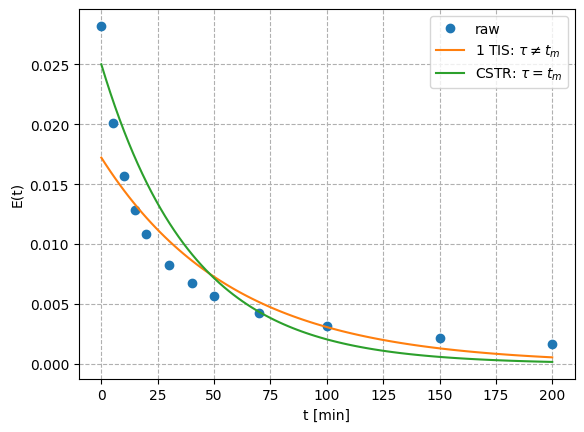

In [335]:
fig, ax = plt.subplots()
ax.plot(t, Es(t), ls='', marker='o', label=f"raw")
tt = np.linspace(t[0], t[-1], 100)
ax.plot(tt, Ncstr(tt, tr, 1), label=r"1 TIS: $\tau \ne t_m$")
ax.plot(tt, Ncstr(tt, tau, 1), label=r"CSTR: $\tau = t_m$")
ax.legend()
ax.grid(ls='--')
ax.set_xlabel("t [min]")
ax.set_ylabel("E(t)")
plt.show()

In [336]:
# calculo de cinetica con modelo de tanques en series (TIS)
# 2A --> B
cA0 = 8 # mol/dm3
k = 0.01 # 1/min
order = 2
r_A = lambda cA: -k*(cA)**(order)
def cstrOptFun(cA, cA0, tau):
    return    cA0 - cA + tau*r_A(cA)

print("Conversion, X")
# conversion
for ntank in [ntanks[1]]:
    tauTIS = tr/ntank
    cEntry = cA0
    for tank in range(ntank):
        cExit = fsolve(cstrOptFun, x0=cEntry, args=(cEntry, tauTIS))
        cEntry = cExit[0]
    x = 1 - cExit[0]/cA0 # conversion after n reactors
    print(f"{ntank} TIS: {x:.4f}")

Conversion, X
1 TIS: 0.6314
